In [42]:
# importing the necessary modules
import numpy as np # creating array, generating synthetic data and mathematical operations.
import matplotlib.pyplot as plt # used to plot the points, curves and visualize it.
# importing linear regression model(polynomial regression = linear regression on transformed features). 
from sklearn.linear_model import LinearRegression 
# convert input features into polynomial terms(this enable us to fit non-linear functions).
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.metrics import mean_squared_error # used to calculate mean_square_error(loss function).
from sklearn.model_selection import train_test_split  # which is used to split the data into training and testing sets.

In [43]:
np.random.seed(42) # it ensures same noise, same data and same results everytime

# Generating Synthetic data
# creates 100 evenly spaced values between -3,3 and converts into 2-D array(required by sklearn) -->(input feature)
x= np.linspace(-3,3,100).reshape(-1,1) 
y= np.sin(x).ravel() + np.random.normal(0,0.2,size=100) '''np.sin(x)->creates non-linear function 
                                                           .ravel() ->converts y into 1-D array 
                                                           np.random.normal -> adds gaussian noise to the data'''

In [44]:
# split the data into train-test
# 20% data for testing, 80% training, ensure same split everytime
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state =42)

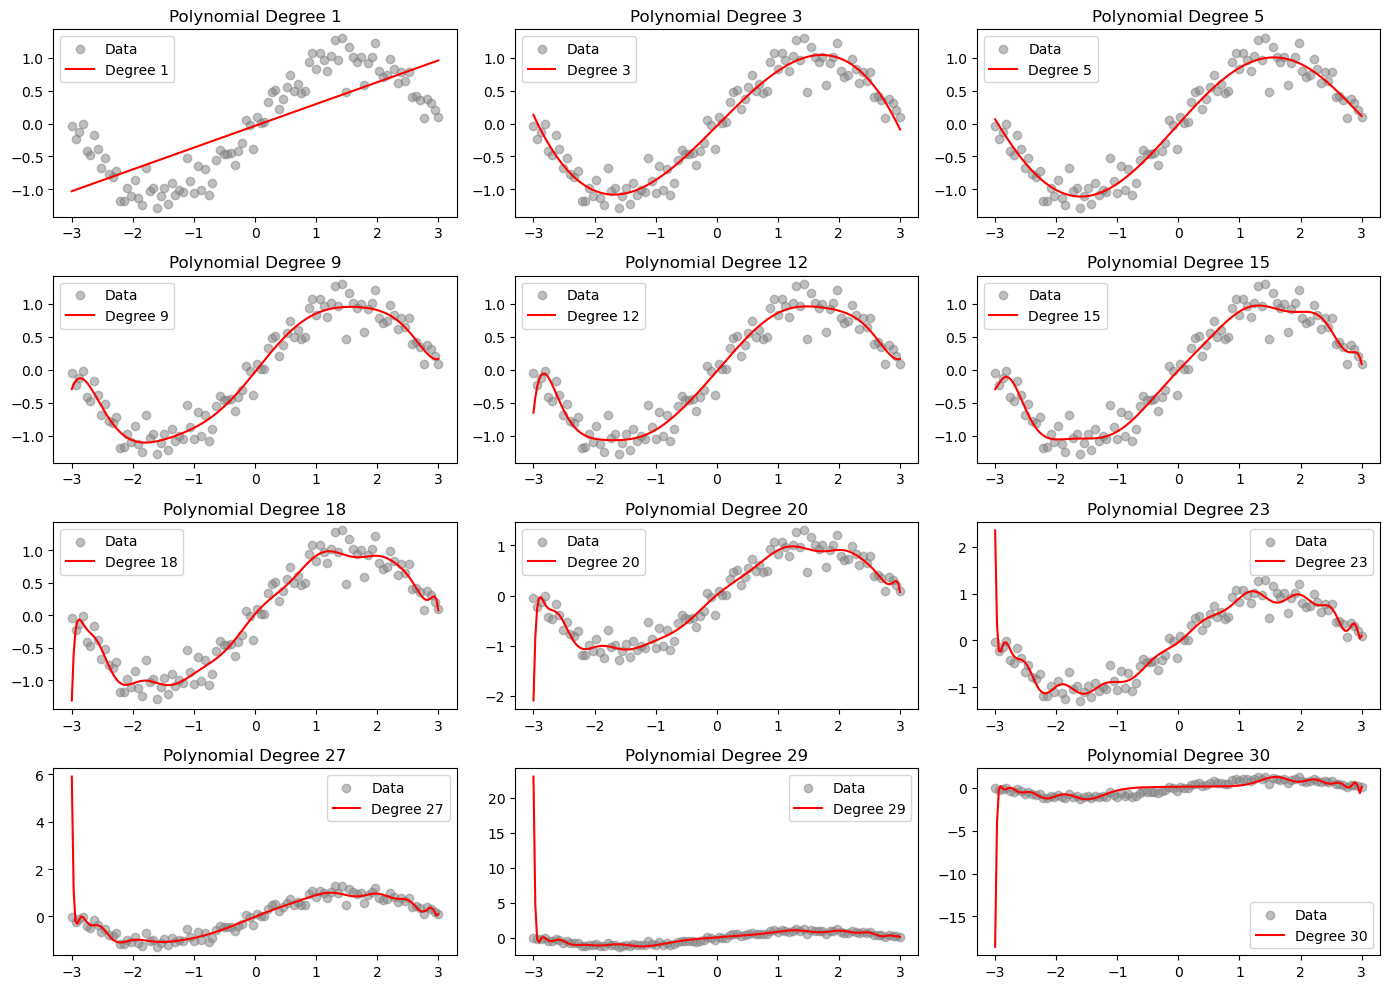

<Figure size 640x480 with 0 Axes>

In [45]:
# Fit and plot polynomial models
degrees = [1,3,5,9,12,15,18,20,23,27,29,30] # choosing polynomial degrees (where it shows the bias-variance tradeoff)
plt.figure(figsize = (14,10))

for i,degree in enumerate(degrees):
    '''PolynomialFeatures converts input data into higher-degree polynomial terms allowing linear regression to model 
     non-linear relationships while ensuring the same transformation is applied to both training and test data.'''
    poly = PolynomialFeatures(degree = degree) # Create a tool that knows how to convert x into [1, x, x², x³, … up to the given degree]
    x_train_poly = poly.fit_transform(x_train) ''' it does 2 things fit - looks at x_train, 
                                                                          learns how many features to create,
                                                                          learns the polynomial structure
                                                                    transform - converts x_train into polynomial features'''
    x_test_poly = poly.transform(x_test) # why no fit here - Test data must not teach the model anything, That would cause data leakage

    model = LinearRegression()
    model.fit(x_train_poly, y_train)
    
    # generates smooth x-values for plotting curves used only to draw the curves(never used to training data)
    x_plot = np.linspace(-3,3,200).reshape(-1,1) 
    #Convert these smooth x-values into the same polynomial feature format that the model understands
    x_plot_poly = poly.transform(x_plot) 
    y_plot = model.predict(x_plot_poly) # generate smooth prediction curve

    plt.subplot(4,3,i+1)
    plt.scatter(x, y, color ='gray', alpha = 0.5, label='Data') # Actual data
    plt.plot(x_plot,y_plot, color='red', label=f'Degree {degree}') # Model prediction
    plt.title(f"Polynomial Degree {degree}")
    plt.legend()

plt.tight_layout()
plt.show()
plt.savefig('my_plot.png') 

In [51]:
import pandas as pd
data = {
    "Polynomial Degree Range": ["Low (1–3)", "Medium (5–9/12)", "High (18–30)"],
    "Bias": ["High", "Balanced", "Low"],
    "Variance": ["Low", "Balanced", "High"],
    "Model Behavior": ["Underfitting", "Best Fit", "Overfitting"]
}
df = pd.DataFrame(data)
df

,Polynomial Degree Range,Bias,Variance,Model Behavior
0,Low (1–3),High,Low,Underfitting
1,Medium (5–9/12),Balanced,Balanced,Best Fit
2,High (18–30),Low,High,Overfitting


# Loss Function in Linear Regression:
In linear regression the goal of the model is to predict the output value as closely as possible to the true value.
To measure how good or bad these predictions are we use a loss function. This loss function gives a single number that represents the total error made by the model on the data.

The most commonly used loss function in linear regression is **mean_squared_error(MSE)**

# squared error loss: 
    for each data point the model makes a prediction.
    the error is the difference between - (true value and predicted value)
    the difference is then squared and the squared over all data points are averaged.
    this avg value is called the mean squared error
# why squared error is used?
    1.it avoids positive and negative errors canceling out
        if we simply add the errors positive and negative differences could cancel each other making the total error appear small even when predictions are poor. squareing ensures that all errors are positive.
    2.it penalizes large values more heavily
        when an error is squared large errors grow much faster than small ones.This forces the model to pay more attention to predictions that are very wrong which improves overall accuracy.
    3.it leads to smooth and stable optimization
        the squared error creates a smooth curve for the loss function, which makes it easier to find the best model parameters using optimization methods. This stability is one reason squared error is preferred in linear regression.
# what minimizing the loss actually means?
    minimizing the loss means adjusting the model so that its predictions are as close as possible to the actual data points
    when the loss is high: the models prediction are far from the true values
                           the model is performing poorly
    when the loss is low: predictions are close to the true values
                          the model is finding the hidden pattern in the data 
    minimizing the loss means finding the best overall fit that reduces the average prediction error across all data points
# how model parameters influence the loss?
    in linear regression the model parameters control the shape of the prediction line
    - changing the parameters changes the predictions
    - changed predictors changed the errors
    - changed errors change the loss
    if the parameters are poorly choosen: predictions are far from true values
                                          loss become large
    if the parameters are well choosen: predictions closely match the data
                                        loss become small
    during training the model continuously adjusts these parameters in order to reduce the loss step by step until it reaches a point where the loss can be reduced further


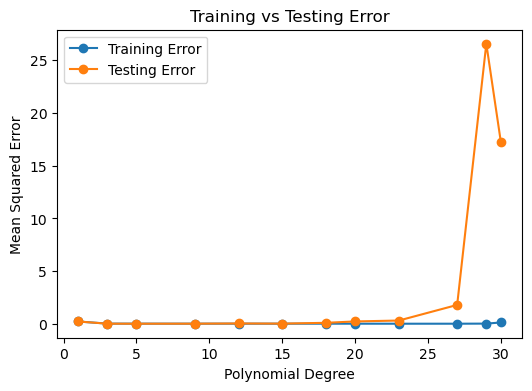

<Figure size 640x480 with 0 Axes>

In [46]:
# Training Errors Vs Testing Errors
train_errors = [] # creating empty lists to store the errors of training 
test_errors = [] # creating empty lists to store the errors of testing

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    # learns polynomial structure from training data, transforms training input into polynomial features
    x_train_poly= poly.fit_transform(x_train) 
    x_test_poly = poly.transform(x_test) # applies same transformation, no fitting here -> prevents data leakage

    model = LinearRegression() # initializing linear model
    model.fit(x_train_poly, y_train) #learn optimal weights by minimizing MSE(this is where loss minimization happens)

    y_train_pred = model.predict(x_train_poly) # predicts output for the training data
    y_test_pred = model.predict(x_test_poly) # predicts output for unseen testing data

    train_errors.append(mean_squared_error(y_train, y_train_pred)) #computes training MSE and stores in train_error list
    test_errors.append(mean_squared_error(y_test, y_test_pred)) #computes testing MSE and stores in test_error list

plt.figure(figsize=(6, 4))
plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, test_errors, marker='o', label="Testing Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Testing Error")
plt.legend()
plt.show()
plt.savefig('train vs test.png') 

# why does training error always decrease with higher potential?
From the training error curve in the training vs testing error graph we can see that the training error steadily goes down with the increase in the degree of the polynomial. This is because with an increase in the degree of the polynomial the number of parameters in the model also increases and hence its flexibility.

When the degree of the polynomial is very high the model becomes capable enough to fit almost all the training data points including the noise in the data. As a result the difference between the predicted and actual values of the training data points becomes very small and hence the training error approaches zero. This behavior is clearly visible in the plot where the training error curve steadily declines without increasing.

# Why does test error behave differently?
Test error initially decreases as the polynomial degree increases because the model starts identifying the true non-linear relationship in the data. after a certain degree test error increases because the model begins to fit noise in the training data which does not generalize to unseen data. This behavior is clearly visible from the rise in test error at higher degrees in the plot.

# At what point does the model start overfitting, and how can you tell?
The model begins to overfit around the polynomial degree of 18-23 and worsens after degree 27. This is the fact from the graph that the training error is very low while the test error is increasing sharply and the prediction curves are highly oscillatory especially around the boundary points.

# If you had to choose one polynomial degree, which would it be and why?
A polynomial degree between 5 and 9 is the best choice because it produces smooth prediction curves, low test error, and a small gap between training and testing error. This range provides the best balance between bias and variance.
